# pyNanoMatBuilder ↔ DebyeCalculator coupling

Minimal tutorial showing how to build a nanoparticle with **pyNanoMatBuilder** and compute its powder X-ray scattering pattern with **DebyeCalculator**(https://github.com/FrederikLizakJohansen/DebyeCalculator/tree/main).

This is a simple, one-off coupling example — it does **not** cover batch/dataset generation over many NPs.

**Required environment / kernel**: `debyecalculator_env`

Create your environment, for example with conda:

```bash
conda create -n debyecalculator_env python=3.11 -y
conda activate debyecalculator_env
```

Install the dependencies:

```bash
pip install -r requirements-debye.txt -e . 
```

Register the kernel if not already done:
```bash
python -m ipykernel install --user --name debyecalculator_env --display-name "Python (debyecalculator_env)"
```

Make sure this notebook is running on the **debyecalculator_env** kernel before executing the cells below.



## 1. Setup

In [1]:
from debyecalculator import DebyeCalculator
from pyNanoMatBuilder import platonicNPs as pNP
import matplotlib.pyplot as plt
from pyNanoMatBuilder import utils as pyNMBu
import numpy as np

## 2. Build a nanoparticle with pyNanoMatBuilder

In [11]:
# Gold icosahedron — any other pyNanoMatBuilder shape class works too
AuNP = pNP.regIco(element='Au', Rnn=2.885, nShell=5,
                  postAnalyzis=True, thresholdCoreSurface=1,
                  skipSymmetryAnalyzis=True, aseView=False, noOutput=True)

pyNMBu.write("coords/AuNP_debye.xyz", AuNP.NP)  

print(f"{len(AuNP.NP)} atoms, circumscribed diameter = "
      f"{AuNP.radiusCircumscribedSphere * 2 / 10:.2f} nm")

561 atoms, circumscribed diameter = 2.74 nm


## 3. Compute the scattering pattern 

X-ray scattering techniques are powerful tools to probe nanoparticle structure. An incident X‑ray beam is scattered by the sample; the scattered intensity is measured as a function of the magnitude Q of the scattering vector (Q = 4π sinθ / λ, with 2θ the scattering angle and λ the wavelength). At small Q (typically Q 
technique is called SAXS (small‑angle X‑ray scattering) and yields information on size, shape and polydispersity; at larger Q (Q ≳ 1 $Å−1$) it is called WAXS (wide-angle X-ray scattering) and it probes atomic arrangements.


The total coherent scattering is given by the Debye formula. Written explicitly:


Equation (1) — full Debye formula
$$
I(Q) \;=\; \sum_{i=1}^{N}\sum_{j=1}^{N} f_i(Q)\,f_j(Q)\,\frac{\sin\bigl(Q\,r_{ij}\bigr)}{Q\,r_{ij}}
$$

- `DebyeCalculator` implements the general Debye formula (Equation 1). The most precise method but scales as $O(N^2)$; use it for relatively small nanoparticles. 
For large particles, we recommend using `pyAUSAXS` that indroduces the efficient approximation of an histogram of interatomic distances. In this case, please refer to `pyNMB-pyausaxs-coupling.ipynb` notebook. 


- `DebyeCalculator` also provides  the structure Function $S(Q)$, the reduced structure function $F(Q)$, and the reduced pair distribution function  $G(r)$.

- In `DebyeCalculator`, GPU with Torch and CUDA can be used for computation acceleration.

You can use `DebyeCalculator` API to compute the scattering intensity step by step (see https://github.com/FrederikLizakJohansen/DebyeCalculator/blob/main/Demo.ipynb) or you can use our function `debye_profile`  which reproduces the same workflow in fewer steps.


### Scattering Intensity

CUDA available: True
DebyeCalculator [iq]: 561 atoms, 19999 points, x-axis = q (1/A), device = cpu


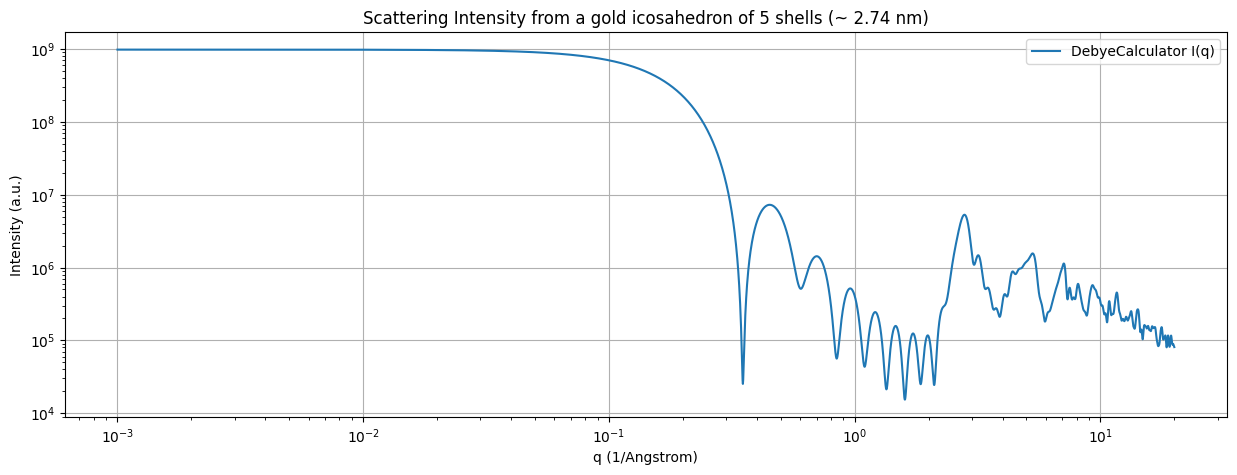

In [ ]:
# The DebyeCalculator package supports GPU acceleration using PyTorch with CUDA
import torch
print("CUDA available:", torch.cuda.is_available())

# Compute the scattering profile I(q) of the NP with DebyeCalculator
q, iq = AuNP.debye_profile(scattering='iq', # change to 'sq', 'fq', or 'gr' for other scattering types
                            qmin=0.001, qmax=20.0, qstep=0.001, biso=0.0, # q range
                             device='cpu', # change to cuda if available
                               xyz_file="coords/AuNP_debye.xyz", # optional: if you want to write the XYZ file
                                 noOutput=False) 

# Save the scattering profile as a text file
# np.savetxt("coords/AuNP_debye.txt", np.column_stack((q, iq)), header="q (1/Angstrom)    Intensity (a.u.)")

# Plot the 
plt.figure(figsize=(15,5))
plt.loglog(q, iq, label="DebyeCalculator I(q)")
plt.yscale('log')
plt.xlabel('q (1/Angstrom)')
plt.ylabel('Intensity (a.u.)')
plt.title('Scattering Intensity from a gold icosahedron of 5 shells (~ 2.74 nm)')
plt.legend()
plt.grid()
plt.show()
plt.close()

*Note: This simulation corresponds to a single size of icosahedrons. Note that, experimentally, nanoparticles in the sample have different sizes. Indeed, there is a size distribution, and the total measured intensity is a weighted average over the size distribution. Please refer to `pyNMB-tutorials.ipynb` to see how to generate this size polydispersity.*


### Reduced Pair distribition function

DebyeCalculator [gr]: 561 atoms, 3000 points, x-axis = r (A), device = cpu


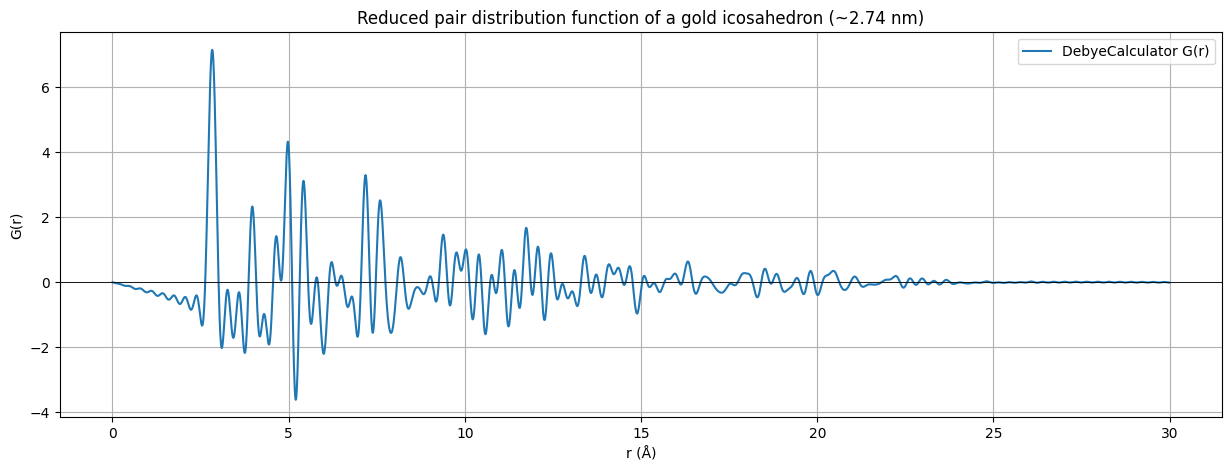

In [10]:
# Reduced pair distribution function G(r) — a REAL-SPACE function.
# Note: for scattering='gr' the first returned axis is r (Angstrom), on the
# r-grid set by rmin/rmax/rstep — NOT the q-grid. The q range still matters:
# it is the Fourier-transform window (qmin acts like a PDF Qmin cut, a larger
# qmax sharpens the peaks).
r, gr = AuNP.debye_profile(scattering='gr',
                           qmin=1.0, qmax=20.0, qstep=0.01,
                           rmin=0.0, rmax=30.0, rstep=0.01,  # rmax > NP diameter (~27 Å)
                           biso=0.0, device='cpu',
                           noOutput=False)

plt.figure(figsize=(15, 5))
plt.plot(r, gr, label="DebyeCalculator G(r)")
plt.axhline(0, color='k', lw=0.6)
plt.xlabel('r (Å)')
plt.ylabel('G(r)')
plt.title('Reduced pair distribution function of a gold icosahedron (~2.74 nm)')
plt.legend()
plt.grid()
plt.show()
plt.close()


## 4. Normalization factor

Normalization factor such that $I(q=0) = 1$. It can be useful for comparison purposes with pyAUSAXS or SasView.

**Normalization factor** (monoatomic case):

$$N_{\text{DebyeCalculator}} = \frac{2}{Z^2 N^2}$$

where:
- $Z$ = atomic number of the element
- $N$ = total number of atoms

For polyatomic systems, adapt the formula by replacing $Z^2$ and $N^2$ with appropriate averages or sums over atomic species.